# DINO Self-Supervised Pretraining — 效果檢驗

在 PadChest-GR train split（3,185 張 X-ray，unlabeled）上重新訓練的 `vit_large` DINO（見 `PLAN.md` Phase 2）。
這份 notebook 用幾種常見、不需要額外訓練標註資料的方式檢查訓練出來的表徵到底有沒有學到東西：

1. **Self-attention 可視化**（DINO 論文最經典的定性檢查）：CLS token 在最後一層對各 patch 的注意力，有沒有聚焦在肺野/心臟等解剖構造上，還是雜訊一片。
2. **Embedding 統計**：檢查有沒有表徵崩塌（collapse）——如果崩塌，所有圖片的 embedding 會幾乎一樣。
3. **PCA 投影**：把 validation split 的 CLS embedding 投影到 2D，用 PadChest-GR 既有的 26 類 classification_labels 上色，看無監督學出來的表徵跟真實病灶標籤有沒有任何對應關係。
4. **Linear probe（定量指標）**：凍結 DINO，只在 CLS embedding 上面訓練一個線性分類器，算每個 label 的 AUROC。這跟 U-VLM Stage 2（ResNet34 encoder + GAP+FC head，macro AUROC 0.7410 / 0.8007）是同一種評估邏輯，可以直接對照「DINO 這樣土炮訓練出來的表徵，跟 U-VLM 監督式訓練的 encoder 比起來如何」。
5. **馬賽克假圖抽查**：看幾張 Phase 3 產生出來、準備餵給 LLaVA 的假圖長什麼樣子。

已知期望：train split 只有 3,185 張圖，遠低於官方 DINO 用的 ImageNet 規模，表徵品質預期會明顯弱於正常 DINO，這份 notebook 就是要老實測出「弱到什麼程度」，而不是預設它會很好。

In [3]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import torchvision.transforms as transforms

sys.path.insert(0, os.path.abspath(".."))
from dino.dino_model_c import load_dino_model
from stage_dino_ssl.dataset import percentile_normalize_uint8

datadrive_project_root = "/datadrive/VLM"
desktop_project_root = "/root/Desktop/VLM"
MANIFEST = f"{desktop_project_root}/data/X-ray/PadChest-GR/processed/manifest.jsonl"
DATA_ROOT = f"{desktop_project_root}/data/X-ray/PadChest-GR/processed"
DINO_CKPT = f"{datadrive_project_root}/DINO_LLM/X-ray/stage_dino_ssl/checkpoints/checkpoint.pth"
MOSAIC_DIR = f"{datadrive_project_root}/DINO_LLM/X-ray/mosaics"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
def load_manifest(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


rows = load_manifest(MANIFEST)
by_split = {}
for r in rows:
    by_split.setdefault(r["split"], []).append(r)
{k: len(v) for k, v in by_split.items()}

{'test': 915, 'train': 3185, 'validation': 455}

In [5]:

model = load_dino_model(DINO_CKPT)
sum(p.numel() for p in model.parameters()) / 1e6, "M params"

Pretrained weights found at /datadrive/VLM/DINO_LLM/X-ray/stage_dino_ssl/checkpoints/checkpoint.pth


(238.42944, 'M params')

## 1. Self-attention 可視化

用 `get_last_selfattention` 拿最後一層 CLS token 對所有 patch token 的注意力（各 head 平均），reshape 回 patch grid、上採樣回原圖大小，疊在原圖上看模型有沒有聚焦在有意義的解剖構造。

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_23345/3647045367.py:52: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_23345/3647045367.py:52: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


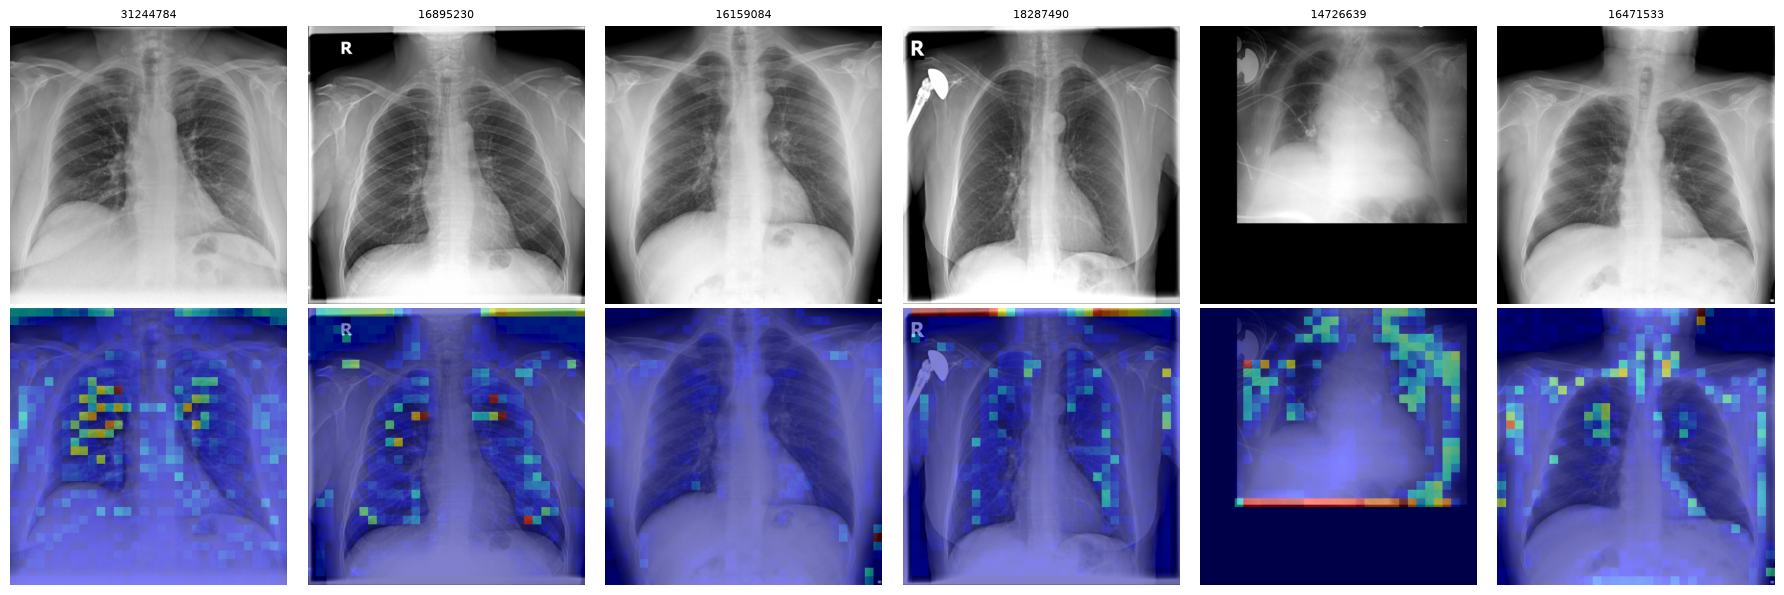

In [12]:
IMG_SIZE = 512
PATCH_SIZE = 16
SSL_CACHE_DIR = os.path.join(DATA_ROOT, "_cache_dino_ssl_r320")  # Phase 2 訓練時已經幫全部
                                                                   # 3,185 張 train split 圖片
                                                                   # 存過 320x320 正規化後的版本
img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5] * 3, [0.5] * 3)])


def load_and_prep(row):
    # PadChest-GR 原圖是 16-bit PNG（mode "I;16"），直接 convert("RGB") 會 naive 轉換、
    # 幾乎全部夾到接近全白（實測平均值 241.95/255）。要先用跟 stage_dino_ssl/dataset.py /
    # U-VLM dataset.py 一致的 percentile normalize 轉成 8-bit 才能看到正確影像。
    #
    # train split（Section 4 linear probe 要跑全部 3,185 張）如果每次都重新讀原圖 + 算
    # percentile 會很慢（實測 ~0.3~0.5 秒/張）。Phase 2 訓練時已經把每張 train 圖存過一份
    # 320x320 正規化後的快取，這裡直接讀那份（一張只要幾毫秒），validation/test 沒有這份
    # 快取（訓練時沒用到），才走原本的慢路徑。
    cache_path = os.path.join(SSL_CACHE_DIR, f"{row['study_id']}.png")
    if os.path.exists(cache_path):
        img = Image.open(cache_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    else:
        img_path = os.path.join(DATA_ROOT, row["image_relpath"])
        arr = percentile_normalize_uint8(np.array(Image.open(img_path)))
        img = Image.fromarray(arr, mode="L").convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    return img, img_transform(img)


@torch.no_grad()
def get_attention_map(model, img_tensor):
    attn = model.get_last_selfattention(img_tensor.unsqueeze(0).to(device))  # (1, heads, N, N)
    n_heads = attn.shape[1]
    grid = IMG_SIZE // PATCH_SIZE
    cls_attn = attn[0, :, 0, 1:].reshape(n_heads, grid, grid)  # CLS -> patch tokens
    cls_attn = cls_attn.mean(0, keepdim=True)  # 平均所有 head
    cls_attn = F.interpolate(cls_attn.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE), mode="nearest")[0, 0]
    return cls_attn.cpu().numpy()


sample_rows = by_split["validation"][:6]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, row in enumerate(sample_rows):
    img, img_tensor = load_and_prep(row)
    attn_map = get_attention_map(model, img_tensor)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(row["study_id"][:8], fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].imshow(attn_map, cmap="jet", alpha=0.5)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("原圖")
axes[1, 0].set_ylabel("CLS attention")
plt.tight_layout()
plt.show()

**怎麼判讀**：如果注意力集中在肺野、心臟輪廓、縱膈等解剖構造上（就算沒有精準到病灶等級），代表 DINO 至少學到「胸腔 X-ray 的整體結構」；如果注意力均勻分散或只聚焦在圖片邊角、文字標記等無關區域，代表這次 self-supervised pretraining 沒有學到有意義的表徵（考慮到只有 3,185 張圖，這是有可能發生的，不用意外）。

## 2. Embedding 統計（檢查有沒有表徵崩塌）

In [13]:
class EmbeddingSourceDataset(Dataset):
    """把 CPU-bound 的 load_and_prep 丟給 DataLoader 的多個 worker 平行做。"""

    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        _, img_tensor = load_and_prep(self.rows[idx])
        return img_tensor, idx


@torch.no_grad()
def extract_embeddings(model, rows, batch_size=32, num_workers=0, desc=""):
    ds = EmbeddingSourceDataset(rows)
    loader = DataLoader(ds, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    embs, ordered_idx = [], []
    for batch_imgs, batch_idx in tqdm(loader, desc=desc):
        embs.append(model(batch_imgs.to(device)).cpu().numpy())
        ordered_idx.extend(batch_idx.tolist())
    embs = np.concatenate(embs, axis=0)
    labels_list = [rows[i].get("classification_labels", {}) for i in ordered_idx]
    study_ids = [rows[i]["study_id"] for i in ordered_idx]
    return embs, labels_list, study_ids


val_embs, val_labels, val_ids = extract_embeddings(model, by_split["validation"], desc="validation embeddings")
val_embs.shape

validation embeddings:  13%|█▎        | 2/15 [02:20<15:11, 70.14s/it]


KeyboardInterrupt: 

In [ ]:
pairwise_cos = val_embs / np.linalg.norm(val_embs, axis=1, keepdims=True)
sim_matrix = pairwise_cos @ pairwise_cos.T
off_diag = sim_matrix[~np.eye(len(sim_matrix), dtype=bool)]
print(f"embedding L2 norm: mean={np.linalg.norm(val_embs, axis=1).mean():.3f} std={np.linalg.norm(val_embs, axis=1).std():.3f}")
print(f"pairwise cosine similarity (off-diagonal): mean={off_diag.mean():.4f} std={off_diag.std():.4f}")
print("如果 mean cosine similarity 接近 1.0、std 接近 0，代表所有圖片的 embedding 幾乎一樣 -> 表徵崩塌。")

embedding L2 norm: mean=35.740 std=0.034
pairwise cosine similarity (off-diagonal): mean=0.3656 std=0.4229
如果 mean cosine similarity 接近 1.0、std 接近 0，代表所有圖片的 embedding 幾乎一樣 -> 表徵崩塌。


## 3. PCA 投影（用真實病灶標籤上色，檢查無監督表徵有沒有捕捉到任何醫學訊號）

explained variance ratio: [0.46766776 0.24545331]


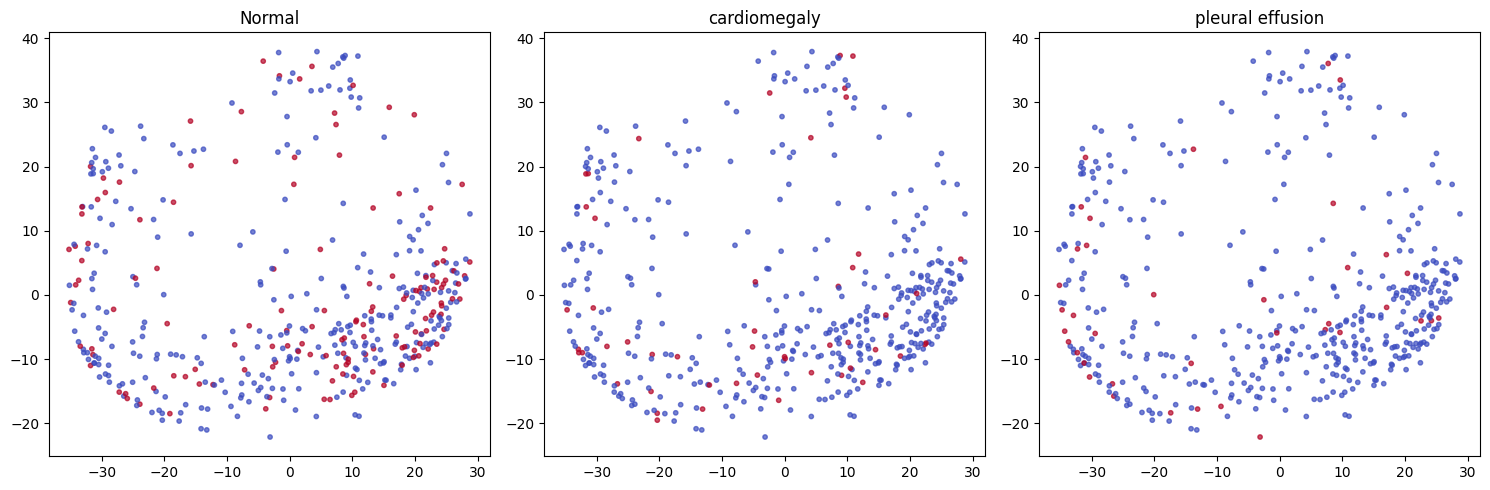

In [ ]:
pca = PCA(n_components=2)
coords = pca.fit_transform(val_embs)
print("explained variance ratio:", pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, label_name in zip(axes, ["Normal", "cardiomegaly", "pleural effusion"]):
    colors = [l.get(label_name, 0) for l in val_labels]
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap="coolwarm", s=10, alpha=0.7)
    ax.set_title(label_name)
plt.tight_layout()
plt.show()

## 4. Linear Probe（定量指標，對照 U-VLM Stage 2 的 macro AUROC）

凍結 DINO，只在 train split 的 CLS embedding 上訓練一個 logistic regression，在 validation split 上算每個
label 的 AUROC。跟 `U-VLM/X-ray/cxr/stage2/checkpoints/eval_per_label_validation.csv` 是同一種評估方式
（U-VLM Stage 2 的 macro AUROC 是 0.8007），可以直接比較「DINO 這樣土炮出來的表徵 vs. U-VLM 監督式訓練的
encoder」。

In [ ]:
train_embs, train_labels, _ = extract_embeddings(model, by_split["train"], desc="train embeddings (cached, should be fast)")
train_embs.shape

train embeddings (cached, should be fast): 100%|██████████| 100/100 [01:38<00:00,  1.02it/s]


(3185, 1280)

In [ ]:
label_names = sorted(train_labels[0].keys())


def to_label_matrix(labels_list, names):
    return np.array([[l.get(n, 0) for n in names] for l in labels_list])


y_train = to_label_matrix(train_labels, label_names)
y_val = to_label_matrix(val_labels, label_names)

aurocs = {}
for i, name in tqdm(enumerate(label_names), total=len(label_names)):
    if y_train[:, i].sum() < 2 or y_val[:, i].sum() < 2:
        continue  # 正樣本太少，AUROC 沒意義（跟 U-VLM eval 的處理方式一致）
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(train_embs, y_train[:, i])
    probs = clf.predict_proba(val_embs)[:, 1]
    aurocs[name] = roc_auc_score(y_val[:, i], probs)

for name, auc in sorted(aurocs.items(), key=lambda kv: -kv[1]):
    print(f"  {name}: AUROC={auc:.4f} (n_pos_val={int(y_val[:, label_names.index(name)].sum())})")
print(f"\nmacro AUROC (DINO linear probe): {np.mean(list(aurocs.values())):.4f}")
print("對照：U-VLM Stage 2（ResNet34 監督式）macro AUROC = 0.8007")

  0%|          | 0/26 [00:00<?, ?it/s]

 15%|█▌        | 4/26 [07:20<42:28, 115.83s/it]

## 5. 馬賽克假圖抽查

Phase 3（`stage_mosaic/build_mosaics.py`）產生的假圖，是接下來要餵進 LLaVA 的東西。這裡直接看幾張，
確認：(a) 不是全黑/全零的退化圖片，(b) 左上角 5 個 16x16 block 有內容、其餘留白符合預期（見 PLAN.md
「必要調整」那段）。

In [ ]:
val_mosaic_dir = os.path.join(MOSAIC_DIR, "validation")
if os.path.isdir(val_mosaic_dir) and os.listdir(val_mosaic_dir):
    sample_files = sorted(os.listdir(val_mosaic_dir))[:6]
    fig, axes = plt.subplots(1, len(sample_files), figsize=(15, 3))
    for ax, fname in zip(axes, sample_files):
        mosaic = Image.open(os.path.join(val_mosaic_dir, fname))
        ax.imshow(mosaic)
        ax.set_title(fname[:10], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"{val_mosaic_dir} 還沒有假圖 —— Phase 3 (build_mosaics.py) 可能還沒跑到 validation split，晚點再重跑這個 cell。")

## 結論欄位（跑完以上各節後手動填）

- Self-attention 有沒有聚焦在解剖構造上：
- Embedding 有沒有崩塌（cosine similarity 是否過高）：
- PCA 投影有沒有看到跟病灶標籤相關的結構：
- Linear probe macro AUROC（跟 U-VLM Stage 2 的 0.8007 相比）：
- 馬賽克假圖是否正常（非退化）：